You are given two integer arrays preorder and inorder.

- preorder is the preorder traversal of a binary tree

- inorder is the inorder traversal of the same tree

- Both arrays are of the same size and consist of unique values.

Rebuild the binary tree from the preorder and inorder traversals and return its root.

Example 1:

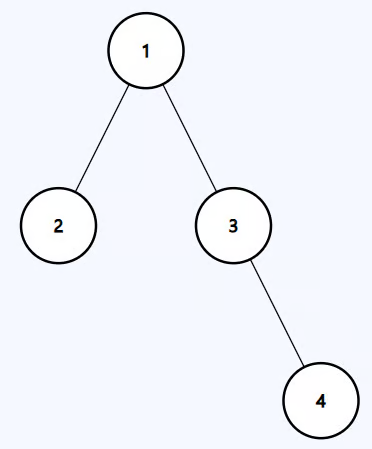

Input: preorder = [1,2,3,4], inorder = [2,1,3,4]

Output: [1,2,3,null,null,null,4]

Example 2:

Input: preorder = [1], inorder = [1]

Output: [1]

In [ ]:
from typing import Optional, List
from collections import deque

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# DFS
# Time Complexity: O(n^2)
# Space Complexity: O(n)
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        if not preorder or not inorder:
            return None

        root_val = preorder[0]
        root = TreeNode(root_val)

        root_index = inorder.index(root_val)

        root.left = self.buildTree(preorder[1:root_index + 1], inorder[:root_index])
        root.right = self.buildTree(preorder[root_index + 1:], inorder[root_index + 1:])

        return root

# Hash Map + Depth First Search

Intuition

In the basic DFS approach, we search for the root's position in inorder using linear search, which takes O(n) time per node. By precomputing a hash map from values to their indices in inorder, we can find the root's position in O(1) time. We also avoid creating new arrays by passing indices that define the current subarray boundaries.

Algorithm

Build a hash map mapping each value in inorder to its index.

Maintain a global preorder index starting at 0.

Define a recursive function dfs(l, r) for the inorder range [l, r].

If l > r, return null (base case).

Get the root value from preorder at the current index, increment the index.

Look up the root's position in the hash map (call it mid).

Recursively build left subtree with dfs(l, mid-1) and right subtree with dfs(mid+1, r).

Return the root node.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        indices = {val: idx for idx, val in enumerate(inorder)}

        self.pre_idx = 0
        def dfs(l, r):
            if l > r:
                return None

            root_val = preorder[self.pre_idx]
            self.pre_idx += 1
            root = TreeNode(root_val)
            mid = indices[root_val]
            root.left = dfs(l, mid - 1)
            root.right = dfs(mid + 1, r)
            return root

        return dfs(0, len(inorder) - 1)

# Depth First Search (Optimal)

Intuition

We can avoid the hash map entirely by using a limit-based approach. Instead of explicitly finding the root's position, we pass a "limit" value that tells us when to stop building the left subtree. When we encounter the limit value in inorder, we know the left subtree is complete. The preorder index tells us which node to create next, and the inorder index tells us when we have finished a subtree.

Algorithm

Maintain two global indices: preIdx for preorder and inIdx for inorder.

Define a recursive function dfs(limit) that builds a subtree until it hits the limit value.

If preIdx >= n, return null (no more nodes).

If inorder[inIdx] == limit, increment inIdx and return null (subtree complete).

Create a root node with preorder[preIdx], increment preIdx.

Build the left subtree with dfs(root.val) since nodes less than root appear before it in inorder.

Build the right subtree with dfs(limit) using the original limit.

Return the root node. Start with dfs(infinity) or a value larger than any node.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n) for recursion stack
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        preIdx = inIdx = 0
        def dfs(limit):
            nonlocal preIdx, inIdx
            if preIdx >= len(preorder):
                return None
            if inorder[inIdx] == limit:
                inIdx += 1
                return None

            root = TreeNode(preorder[preIdx])
            preIdx += 1
            root.left = dfs(root.val)
            root.right = dfs(limit)
            return root
        return dfs(float('inf'))

# Morris Traversal

Intuition

Morris traversal allows us to build the tree iteratively without using a recursion stack. The idea is to use the right pointers of nodes to temporarily store parent references, simulating the call stack. We build nodes as we iterate through preorder, connecting them via left/right pointers. When we finish a left subtree (detected by matching the inorder sequence), we restore the original structure by clearing temporary links and moving up the tree.

Algorithm

Create a dummy head node and set curr to point to it.

Iterate through preorder with index i and inorder with index j.

Create a new node for preorder[i] and attach it as curr's right child, then move curr to this new node.

While preorder[i] does not match inorder[j], keep creating left children (storing parent in right pointer).

When a match is found, increment j. While curr.right exists and matches inorder[j], clear the temporary right link and move up.

Continue until all nodes are processed.

Return head.right as the actual root.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: 
# O(1) extra space.
# O(n) for the output tree.
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        head = TreeNode(None)
        curr = head
        i, j, n = 0, 0, len(preorder)
        while i < n and j < n:
            # Go right and then as far left as possible
            curr.right = TreeNode(preorder[i], right = curr.right)
            curr = curr.right
            i += 1
            while i < n and curr.val != inorder[j]:
                curr.left = TreeNode(preorder[i], right=curr)
                curr = curr.left
                i += 1
            j += 1
            while curr.right and j < n and curr.right.val == inorder[j]:
                prev = curr.right
                curr.right = None
                curr = prev
                j += 1

        return head.right